In [1]:
!pip install numpy pandas matplotlib scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [3]:
data = [
    [0,0,0],
    [0,0,0],
    [1,0,0],
    [2,0,0],
    [2,1,1],
    [2,1,1],
    [1,1,1],
    [0,1,0],
    [2,0,1],
    [0,1,1]
]

df = pd.DataFrame(data, columns=['Age','Income','Buy'])

print(df)

   Age  Income  Buy
0    0       0    0
1    0       0    0
2    1       0    0
3    2       0    0
4    2       1    1
5    2       1    1
6    1       1    1
7    0       1    0
8    2       0    1
9    0       1    1


In [4]:
labels = df['Buy'].values

n_total = len(labels)
n_yes = sum(labels)
n_no = n_total - n_yes

p_yes = n_yes / n_total
p_no = n_no / n_total

gini = 1 - (p_yes**2 + p_no**2)

print("Gini Impurity:", gini)

Gini Impurity: 0.5


In [5]:
entropy = 0

if p_yes > 0:
    entropy -= p_yes * np.log2(p_yes)

if p_no > 0:
    entropy -= p_no * np.log2(p_no)

print("Entropy:", entropy)

Entropy: 1.0


In [6]:
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset shape:", X.shape)

Dataset shape: (150, 4)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [8]:
dt_gini = DecisionTreeClassifier(criterion="gini", max_depth=3)

dt_gini.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [9]:
dt_entropy = DecisionTreeClassifier(criterion="entropy", max_depth=3)

dt_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

In [11]:
y_pred_gini = dt_gini.predict(X_test)

y_pred_entropy = dt_entropy.predict(X_test)

In [12]:
acc_gini = accuracy_score(y_test, y_pred_gini)

acc_entropy = accuracy_score(y_test, y_pred_entropy)

print("Gini Accuracy:", acc_gini)
print("Entropy Accuracy:", acc_entropy)

Gini Accuracy: 1.0
Entropy Accuracy: 1.0


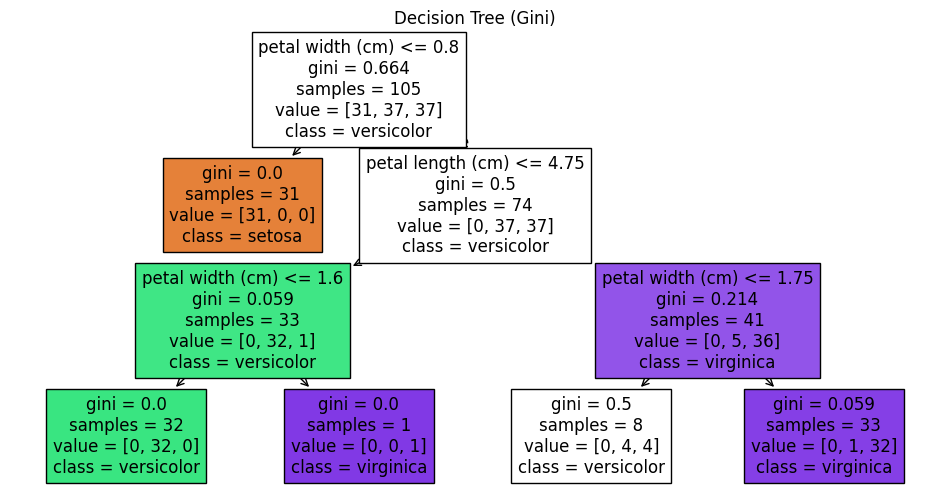

In [13]:
plt.figure(figsize=(12,6))

plot_tree(dt_gini,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True)

plt.title("Decision Tree (Gini)")
plt.show()

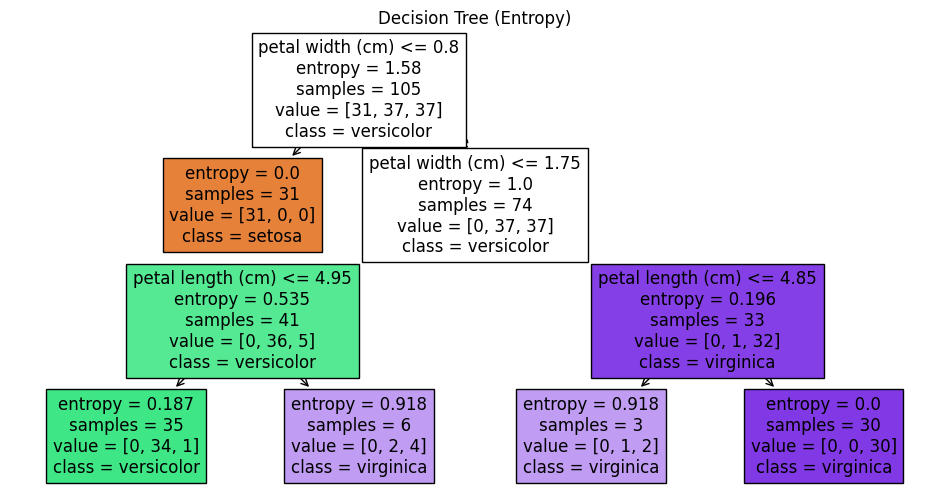

In [14]:
plt.figure(figsize=(12,6))

plot_tree(dt_entropy,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True)

plt.title("Decision Tree (Entropy)")
plt.show()

In [15]:
importance = dt_gini.feature_importances_

for name, score in zip(iris.feature_names, importance):
    print(name, ":", score)

sepal length (cm) : 0.0
sepal width (cm) : 0.0
petal length (cm) : 0.41170735677191017
petal width (cm) : 0.5882926432280897
